# Hệ Thống Phát Hiện Chi Phí Bất Thường - FinOps Watch (Phiên Bản 3 - Đa Phân Lớp & Walk-Forward)

Notebook này triển khai bộ máy phát hiện chi phí bất thường (Anomaly Detection Engine) ở mức độ chi tiết **tài nguyên × ngày** (resource × day), sử dụng mô hình học máy **phân loại đa lớp (Multiclass Classification: Normal, Anomaly, Benign)** và chiến lược đánh giá **Walk-Forward Validation** (3 Folds).

## 🛠️ Các cải tiến cốt lõi trong Phiên Bản 3:
1. **Phân loại rõ ràng 3 lớp**: Phân biệt rõ ràng giữa các tài nguyên **Normal** (0 - bình thường), **Anomaly** (1 - bất thường thực sự), và **Benign** (2 - tăng chi phí hợp lý có kế hoạch, ví dụ: Flash Sale, Batch Job, Migration).
2. **Chiến lược Walk-Forward Validation**: Đánh giá hiệu năng mô hình qua 3 cửa sổ trượt tịnh tiến theo thời gian (expanding windows) mô phỏng chính xác quá trình vận hành thực tế.
3. **Trực quan hóa đa dạng**: Vẽ biểu đồ phân phối các lớp dữ liệu, biểu đồ chuỗi thời gian (Timeseries) chi phí của các lớp, và sơ đồ phân chia dữ liệu Walk-Forward.
4. **Kỹ nghệ đặc trưng & Chuẩn hóa Chống rò rỉ dữ liệu (Leak-Proof)**: 
   * Các đặc trưng tĩnh toàn cục (`weekend_ratio`) được tính toán **bên trong vòng lặp**, chỉ sử dụng dữ liệu của tập Train tại fold đó và map sang tập Test.
   * Bộ chuẩn hóa `RobustScaler` được fit độc lập trên tập Train của mỗi fold và áp dụng (`transform`) cho tập Test của fold đó.
5. **Hiệu chuẩn ngưỡng tối ưu chống rò rỉ**: Áp dụng kiểm thử chéo `GroupKFold` theo `resource_id` bên trong mỗi fold huấn luyện để tìm ngưỡng xác suất tối ưu cho Anomaly nhằm bảo đảm Precision của lớp Anomaly `>= 80%`.

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import xgboost as xgb
import shap
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve, 
    roc_curve, auc, f1_score, matthews_corrcoef, balanced_accuracy_score
)
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
from scipy.stats import linregress
import hashlib


C:\Users\ASUS\OneDrive\Obsidian Vault\XBrain-Phase2\Capstone_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Đường dẫn dữ liệu (tương đối từ thư mục notebook)
CUR_PATH = os.path.join("..", "..", "data", "tf2-finops", "cur_line_items.csv")
METRICS_DIR = os.path.join("..", "..", "data", "metrics_haikhoa")

print(f"Đang tải dữ liệu CUR từ: {CUR_PATH}...")
cur = pd.read_csv(CUR_PATH)
cur['date'] = pd.to_datetime(cur['line_item_usage_start_date']).dt.tz_localize(None)

print(f"Đang tải dữ liệu metrics hệ thống từ: {METRICS_DIR}...")
metrics_files = glob.glob(os.path.join(METRICS_DIR, "*.csv"))
dfs = []
for f in metrics_files:
    print(f"  Đọc file metrics: {os.path.basename(f)}...")
    dfs.append(pd.read_csv(f))
metrics = pd.concat(dfs, ignore_index=True)
metrics['date'] = pd.to_datetime(metrics['timestamp']).dt.tz_localize(None)

# Điền giá trị NaN cho các cột metrics của các dịch vụ không tương ứng
metrics_cols = ['cpu_percent', 'memory_mib', 'network_in_bytes', 'network_out_bytes', 'disk_io_ops', 'database_connections', 'gpu_utilization']
cpu_h_cols = [f'cpu_h{i}' for i in range(24)]
for col in metrics_cols + cpu_h_cols:
    if col in metrics.columns:
        metrics[col] = metrics[col].fillna(0.0)
    else:
        metrics[col] = 0.0

print("Đang kết nối dữ liệu chi phí và hiệu năng hệ thống...")
df = pd.merge(cur, metrics, left_on=['line_item_resource_id', 'date'], right_on=['resource_id', 'date'], how='inner')
print(f"Kích thước dữ liệu hợp nhất: {df.shape}")

Đang tải dữ liệu CUR từ: ..\..\data\tf2-finops\cur_line_items.csv...
Đang tải dữ liệu metrics hệ thống từ: ..\..\data\metrics_haikhoa...
  Đọc file metrics: ddb_metrics.csv...
  Đọc file metrics: ec2_metrics.csv...
  Đọc file metrics: other_services_metrics.csv...
  Đọc file metrics: rds_metrics.csv...
  Đọc file metrics: sagemaker_metrics.csv...
Đang kết nối dữ liệu chi phí và hiệu năng hệ thống...
Kích thước dữ liệu hợp nhất: (24533, 58)


### Trực quan hóa 1: Phân phối số lượng các lớp dữ liệu (Normal, Anomaly, Benign)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27660\1463153332.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2')


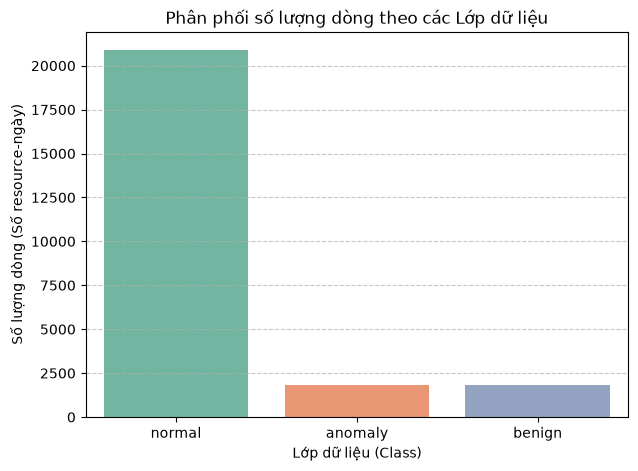

In [3]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Phân phối số lượng dòng theo các Lớp dữ liệu')
plt.xlabel('Lớp dữ liệu (Class)')
plt.ylabel('Số lượng dòng (Số resource-ngày)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Trực quan hóa 2: Biểu đồ chuỗi thời gian (Timeseries) chi phí hàng ngày của các lớp dữ liệu

Biểu đồ này biểu diễn tổng chi phí phát sinh hàng ngày của từng lớp dữ liệu. Nhìn vào biểu đồ ta có thể thấy các ngày có chi phí bất thường (Anomaly) và các ngày có đợt tăng chi phí hợp lý có kế hoạch (Benign).

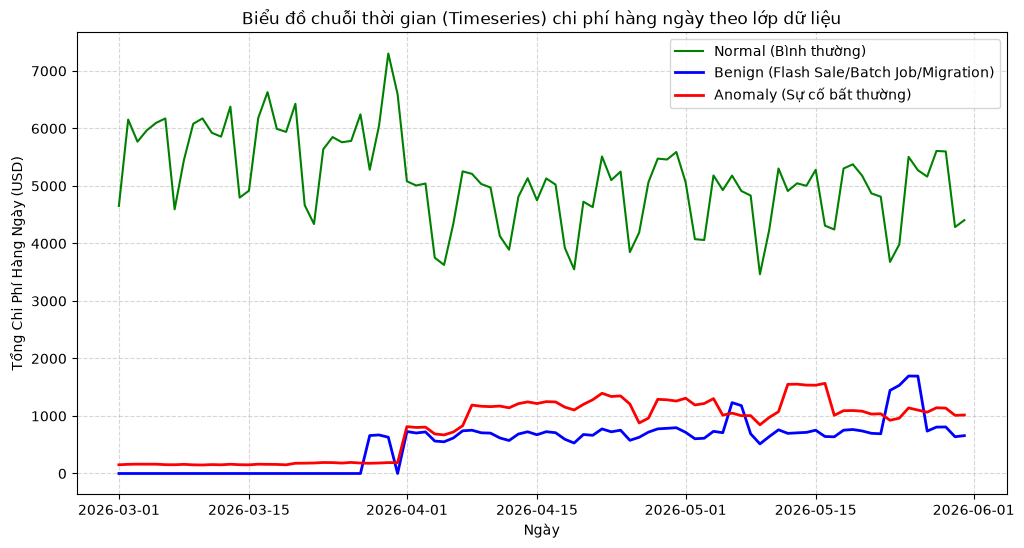

In [4]:
daily_cost = df.groupby(['date', 'label'])['line_item_unblended_cost'].sum().unstack(fill_value=0.0)

plt.figure(figsize=(12, 6))
plt.plot(daily_cost.index, daily_cost['normal'], label='Normal (Bình thường)', color='green', lw=1.5)
plt.plot(daily_cost.index, daily_cost['benign'], label='Benign (Flash Sale/Batch Job/Migration)', color='blue', lw=2)
plt.plot(daily_cost.index, daily_cost['anomaly'], label='Anomaly (Sự cố bất thường)', color='red', lw=2)
plt.title('Biểu đồ chuỗi thời gian (Timeseries) chi phí hàng ngày theo lớp dữ liệu')
plt.xlabel('Ngày')
plt.ylabel('Tổng Chi Phí Hàng Ngày (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Trực quan hóa 3: Thiết lập chiến lược chia dữ liệu Walk-Forward Validation

Chúng ta thiết lập 3 cửa sổ trượt (Folds) dựa trên dòng thời gian thực tế từ 01/03 đến 31/05/2026 (92 ngày):
- **Fold 1**: Huấn luyện 50 ngày đầu (ngày 0-50), Kiểm thử 14 ngày tiếp theo (ngày 51-64).
- **Fold 2**: Huấn luyện 64 ngày đầu (ngày 0-64), Kiểm thử 14 ngày tiếp theo (ngày 65-78).
- **Fold 3**: Huấn luyện 78 ngày đầu (ngày 0-78), Kiểm thử 13 ngày cuối cùng (ngày 79-91).

Tổng số ngày trong tập dữ liệu: 92 ngày (Từ 2026-03-01 đến 2026-05-31)


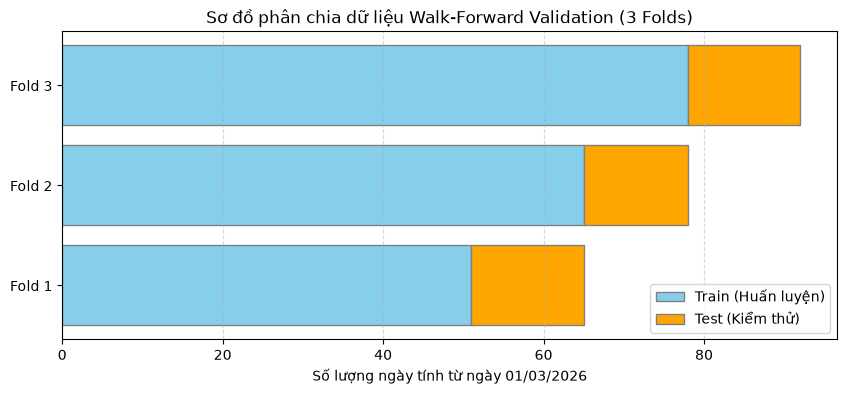

In [5]:
timeline = sorted(df['date'].unique())
print(f"Tổng số ngày trong tập dữ liệu: {len(timeline)} ngày (Từ {timeline[0].strftime('%Y-%m-%d')} đến {timeline[-1].strftime('%Y-%m-%d')})")

# Trực quan hóa sơ đồ chia dữ liệu
fig, ax = plt.subplots(figsize=(10, 4))
folds_def = [
    ("Fold 1", timeline[:51], timeline[51:65]),
    ("Fold 2", timeline[:65], timeline[65:78]),
    ("Fold 3", timeline[:78], timeline[78:])
]

for i, (fold_name, train_d, test_d) in enumerate(folds_def):
    ax.barh(fold_name, len(train_d), left=0, color='skyblue', edgecolor='grey', label='Train (Huấn luyện)' if i==0 else "")
    ax.barh(fold_name, len(test_d), left=len(train_d), color='orange', edgecolor='grey', label='Test (Kiểm thử)' if i==0 else "")

ax.set_xlabel('Số lượng ngày tính từ ngày 01/03/2026')
ax.set_title('Sơ đồ phân chia dữ liệu Walk-Forward Validation (3 Folds)')
ax.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

## Bước 4: Kỹ nghệ đặc trưng hành vi và hiệu năng (Feature Engineering)

Mô hình sử dụng các đặc trưng hành vi hệ thống và đặc trưng hiệu suất được tính toán trên cửa sổ trượt (rolling window) của từng tài nguyên. 
*(Lưu ý: Đặc trưng tĩnh `weekend_ratio` sẽ được tính toán động bên trong vòng lặp của từng fold để tránh rò rỉ dữ liệu từ tương lai)*

In [6]:
print("Đang tính toán các đặc trưng hành vi và các chỉ số hiệu suất...")
df = df.sort_values(by=['line_item_resource_id', 'date']).reset_index(drop=True)
group = df.groupby('line_item_resource_id')

# 1. Tính toán độ lệch chi phí Z-score/MAD (Nhân quả - không gây leak)
df['cost_rolling_median_28d'] = group['line_item_unblended_cost'].transform(
    lambda x: x.shift(1).rolling(window=28, min_periods=1).median()
)
df['cost_rolling_mad_28d'] = group['line_item_unblended_cost'].transform(
    lambda x: x.shift(1).rolling(window=28, min_periods=1).apply(
        lambda w: np.median(np.abs(w - np.median(w))) if len(w) > 0 else 0.0, raw=True
    )
)
df['cost_z'] = (df['line_item_unblended_cost'] - df['cost_rolling_median_28d']) / (1.4826 * df['cost_rolling_mad_28d'] + 1e-5)

# 2. Tính toán đặc trưng xu hướng chi phí
df['cost_change_28d'] = group['line_item_unblended_cost'].transform(
    lambda x: (x - x.shift(28)) / (x.shift(28) + 1e-5)
).fillna(0)

def get_slope(y):
    if len(y) < 2:
        return 0.0
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope

df['cost_slope_14d'] = group['line_item_unblended_cost'].transform(
    lambda x: x.shift(1).rolling(window=14, min_periods=2).apply(get_slope, raw=True)
).fillna(0)

# 3. CPU & Network utilization Z-score (MỚI - giải quyết leakage & Flash Sale)
df['cpu_rolling_median_28d'] = group['cpu_percent'].transform(
    lambda x: x.shift(1).rolling(window=28, min_periods=1).median()
)
df['cpu_rolling_mad_28d'] = group['cpu_percent'].transform(
    lambda x: x.shift(1).rolling(window=28, min_periods=1).apply(
        lambda w: np.median(np.abs(w - np.median(w))) if len(w) > 0 else 0.0, raw=True
    )
)
df['cpu_z'] = (df['cpu_percent'] - df['cpu_rolling_median_28d']) / (1.4826 * df['cpu_rolling_mad_28d'] + 1e-5)

df['net_total'] = df['network_in_bytes'] + df['network_out_bytes']
df['net_rolling_median_28d'] = group['net_total'].transform(
    lambda x: x.shift(1).rolling(window=28, min_periods=1).median()
)
df['net_rolling_mad_28d'] = group['net_total'].transform(
    lambda x: x.shift(1).rolling(window=28, min_periods=1).apply(
        lambda w: np.median(np.abs(w - np.median(w))) if len(w) > 0 else 0.0, raw=True
    )
)
df['net_z'] = (df['net_total'] - df['net_rolling_median_28d']) / (1.4826 * df['net_rolling_mad_28d'] + 1e-5)

df['cpu_change_28d'] = group['cpu_percent'].transform(
    lambda x: (x - x.shift(28)) / (x.shift(28) + 1e-5)
).fillna(0)

df['cpu_slope_14d'] = group['cpu_percent'].transform(
    lambda x: x.shift(1).rolling(window=14, min_periods=2).apply(get_slope, raw=True)
).fillna(0)

# 4. Tương quan hiệu suất chi phí và hiệu năng (Efficiency ratios)
df['cost_cpu_z_ratio'] = df['cost_z'] / (df['cpu_z'].abs() + 1e-5)
df['cost_util_divergence'] = df['cost_change_28d'] - df['cpu_change_28d']

# 5. Đặc trưng chu kỳ thời gian cơ bản
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)
df['day_of_week'] = df['date'].dt.dayofweek
df['weekend_ratio'] = 0.0  # sẽ tính chi tiết theo từng fold train

# 6. Các chỉ số hiệu suất liên kết chi phí và metrics hệ thống
df['cost_per_cpu'] = df['line_item_unblended_cost'] / (df['cpu_percent'] + 1e-5)
df['cost_per_memory'] = df['line_item_unblended_cost'] / (df['memory_mib'] + 1e-5)
df['cost_per_network_in'] = df['line_item_unblended_cost'] / (df['network_in_bytes'] + 1e-5)
df['cost_per_network_out'] = df['line_item_unblended_cost'] / (df['network_out_bytes'] + 1e-5)
df['cost_per_disk_io'] = df['line_item_unblended_cost'] / (df['disk_io_ops'] + 1e-5)
df['cost_per_db_conn'] = df['line_item_unblended_cost'] / (df['database_connections'] + 1e-5)
df['cost_per_gpu'] = df['line_item_unblended_cost'] / (df['gpu_utilization'] + 1e-5)
df['usage_density'] = df['line_item_usage_amount'] / 24.0

# 7. Tính toán tag completeness và so sánh đồng loại (peer ratio)
df['team_missing'] = (df['resource_tags_user_team'].isna() | (df['resource_tags_user_team'] == '')).astype(int)
df['owner_missing'] = (df['resource_tags_user_owner'].isna() | (df['resource_tags_user_owner'] == '')).astype(int)

peer_medians = df.groupby(['date', 'line_item_usage_account_name', 'line_item_product_code'])['line_item_unblended_cost'].transform('median')
df['peer_ratio'] = df['line_item_unblended_cost'] / (peer_medians + 1e-5)

# 8. Số ngày tuổi
first_seen = df.groupby('line_item_resource_id')['date'].transform('min')
df['age_days'] = (df['date'] - first_seen).dt.days

# 9. Đặc trưng so sánh peer hàng ngày (Daily Peer - Cold Start mitigation)
peer_cost_mads = df.groupby(['date', 'line_item_usage_account_name', 'line_item_product_code'])[
    'line_item_unblended_cost'].transform(
        lambda x: np.median(np.abs(x - np.median(x))) if len(x) > 0 else 0.0
    )
df['peer_cost_z'] = (df['line_item_unblended_cost'] - peer_medians) / (1.4826 * peer_cost_mads + 1e-5)

peer_cpu_medians = df.groupby(['date', 'line_item_usage_account_name', 'line_item_product_code'])[
    'cpu_percent'].transform('median')
peer_cpu_mads = df.groupby(['date', 'line_item_usage_account_name', 'line_item_product_code'])[
    'cpu_percent'].transform(
        lambda x: np.median(np.abs(x - np.median(x))) if len(x) > 0 else 0.0
    )
df['peer_cpu_z'] = (df['cpu_percent'] - peer_cpu_medians) / (1.4826 * peer_cpu_mads + 1e-5)

peer_net_medians = df.groupby(['date', 'line_item_usage_account_name', 'line_item_product_code'])[
    'net_total'].transform('median')
peer_net_mads = df.groupby(['date', 'line_item_usage_account_name', 'line_item_product_code'])[
    'net_total'].transform(
        lambda x: np.median(np.abs(x - np.median(x))) if len(x) > 0 else 0.0
    )
df['peer_net_z'] = (df['net_total'] - peer_net_medians) / (1.4826 * peer_net_mads + 1e-5)

df['peer_cost_cpu_ratio'] = df['peer_cost_z'] / (df['peer_cpu_z'].abs() + 1e-5)
df['peer_cost_net_ratio'] = df['peer_cost_z'] / (df['peer_net_z'].abs() + 1e-5)

# Tập hợp các đặc trưng cuối cùng
feature_cols = [
    'line_item_unblended_cost', 'line_item_usage_amount',
    # Raw metrics
    'cpu_percent', 'memory_mib', 'network_in_bytes', 'network_out_bytes',
    'disk_io_ops', 'database_connections', 'gpu_utilization',
    # Cost-derived (giữ nhưng đã có counterbalance từ utilization features)
    'cost_z', 'cost_change_28d', 'cost_slope_14d',
    # MỚI: Utilization z-scores & changes (counterbalance cost features)
    'cpu_z', 'net_z', 'cpu_change_28d', 'cpu_slope_14d',
    # MỚI: Efficiency ratios (KEY differentiation features)
    'cost_cpu_z_ratio', 'cost_util_divergence',
    # MỚI: Daily peer features (Cold Start mitigation)
    'peer_cost_z', 'peer_cpu_z', 'peer_net_z', 'peer_cost_cpu_ratio', 'peer_cost_net_ratio',
    # Time features
    'is_weekend', 'day_of_week', 'weekend_ratio',
    # Cost efficiency
    'cost_per_cpu', 'cost_per_memory', 'cost_per_network_in',
    'cost_per_network_out', 'cost_per_disk_io', 'cost_per_db_conn',
    'cost_per_gpu',
    # Other
    'usage_density', 'team_missing', 'owner_missing', 'peer_ratio', 'age_days'
] + cpu_h_cols

# Làm sạch các giá trị vô cực
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Drop các cột trung gian
for col in ['cpu_rolling_median_28d', 'cpu_rolling_mad_28d',
            'net_rolling_median_28d', 'net_rolling_mad_28d',
            'cost_rolling_median_28d', 'cost_rolling_mad_28d',
            'net_total', 'peer_net_medians', 'peer_net_mads']:
    if col in df.columns:
        df = df.drop(columns=[col])


Đang tính toán các đặc trưng hành vi và các chỉ số hiệu suất...


## Bước 5: Thực thi Vòng lặp Đánh giá Walk-Forward Validation Chống rò rỉ dữ liệu (3 Folds)

Trong mỗi Fold của quá trình Walk-Forward, chúng ta thực hiện các bước kiểm thử khắt khe:
1. Chia tách tập Train/Test theo mốc thời gian của Fold.
2. **Kỹ nghệ đặc trưng động tĩnh chống leak**: Tính toán `weekend_ratio` **chỉ dựa trên tập Train của fold**, rồi `map` giá trị này cho cả tập Train và Test.
3. Chạy **GroupKFold cross-validation** (5 folds) chia theo nhóm `resource_id` trên dữ liệu Train của Fold đó.
4. **Chuẩn hóa RobustScaler chống leak**: Khởi tạo và `fit_transform` scaler trên tập huấn luyện chéo của fold, rồi `transform` tập Validation.
5. Sử dụng đường cong **Precision-Recall Curve** trên dự đoán OOF để lựa chọn ngưỡng tối ưu $t_{anomaly}$ sao cho Precision của riêng lớp Anomaly đạt ít nhất **80.00%**.
6. Huấn luyện mô hình đa phân lớp XGBoost final của Fold bằng cách áp dụng trọng số mẫu `sample_weight` tự động để cân bằng lớp dữ liệu.
7. Dự đoán trên tập Test của Fold và thực thi quy tắc hậu xử lý ngưỡng để ưu tiên phát hiện đúng Anomaly:
   * Nếu xác suất dự báo lớp Anomaly $p_1 \ge t_{anomaly} \rightarrow$ gán nhãn dự báo là Anomaly.
   * Ngược lại, nếu xác suất dự báo lớp Benign $p_2 \ge 0.20 \rightarrow$ gán nhãn dự báo là Benign.
   * Ngược lại $ightarrow$ lấy nhãn có xác suất cao nhất (thường là Normal).
8. Đánh giá chi tiết bằng Classification Report đa lớp, vẽ Confusion Matrix Heatmap, vẽ đường cong Precision-Recall Curve dùng để chọn ngưỡng, phân tích Recall theo từng loại sự cố Anomaly và False Alarm Rate theo từng loại sự kiện Benign.
9. Giải thích đóng góp đặc trưng bằng biểu đồ **SHAP Summary Plot** cho riêng từng Fold.


                  BẮT ĐẦU THỰC THI FOLD 1 (51 Ngày Train -> 14 Ngày Test)
[PHÂN PHỐI NHÃN HUẤN LUYỆN]: Normal: 12302 | Anomaly: 679 | Benign: 603


[ĐÃ HIỆU CHUẨN NGƯỠNG ANOMALY]: Ngưỡng được lựa chọn = 0.0265



--- BÁO CÁO CHẤT LƯỢNG MÔ HÌNH TRÊN TẬP TEST CỦA FOLD 1 ---
              precision    recall  f1-score   support

      normal       1.00      0.96      0.98      2926
     anomaly       0.78      0.98      0.87       410
      benign       1.00      1.00      1.00       420

    accuracy                           0.97      3756
   macro avg       0.93      0.98      0.95      3756
weighted avg       0.97      0.97      0.97      3756

Ma trận nhầm lẫn (Confusion Matrix):
[[2814  112    0]
 [   7  403    0]
 [   0    1  419]]


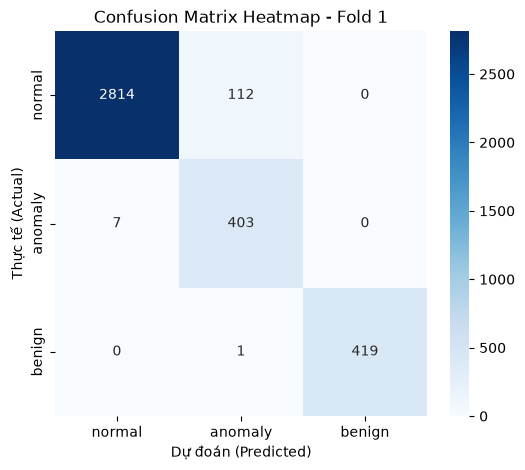

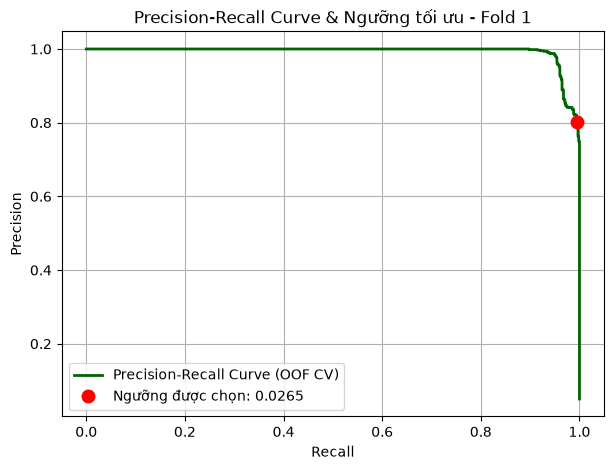


--- PHÂN TÍCH RECALL THEO TỪNG LOẠI SỰ CỐ ANOMALY THẬT (FOLD 1) ---
Loại Anomaly: gradual_drift (DynamoDB Drift)      | Tổng số ngày: 14   | Phát hiện được: 14   | Recall: 100.00%
Loại Anomaly: gradual_drift (Memory Leak)         | Tổng số ngày: 84   | Phát hiện được: 84   | Recall: 100.00%
Loại Anomaly: idle_resource (Orphan EBS)          | Tổng số ngày: 14   | Phát hiện được: 14   | Recall: 100.00%
Loại Anomaly: idle_resource (Orphan RDS)          | Tổng số ngày: 14   | Phát hiện được: 14   | Recall: 100.00%
Loại Anomaly: runaway_usage (DB Saturation)       | Tổng số ngày: 56   | Phát hiện được: 56   | Recall: 100.00%
Loại Anomaly: runaway_usage (GPU Runaway)         | Tổng số ngày: 25   | Phát hiện được: 25   | Recall: 100.00%
Loại Anomaly: sudden_spike (CPU Spike)            | Tổng số ngày: 70   | Phát hiện được: 70   | Recall: 100.00%
Loại Anomaly: sudden_spike (DDoS Traffic)         | Tổng số ngày: 84   | Phát hiện được: 84   | Recall: 100.00%
Loại Anomaly: sudden_spike (Debug L

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27660\2796618918.py:212: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_anomaly, X_test_f_scaled, feature_names=feature_cols, show=False)


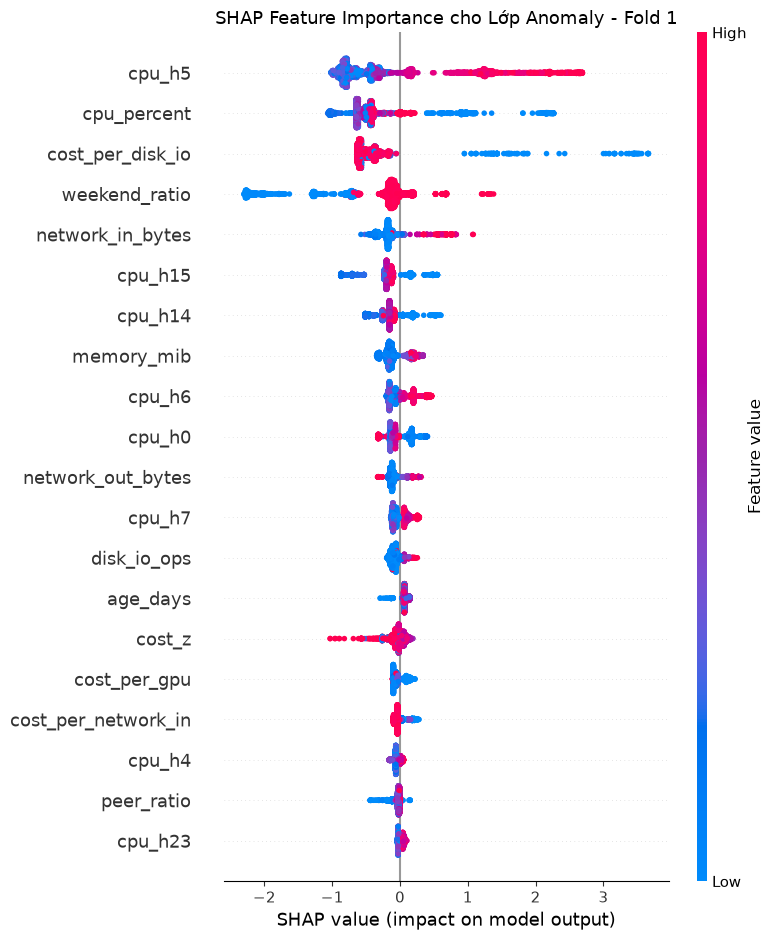


                  BẮT ĐẦU THỰC THI FOLD 2 (65 Ngày Train -> 13 Ngày Test)
[PHÂN PHỐI NHÃN HUẤN LUYỆN]: Normal: 15228 | Anomaly: 1089 | Benign: 1023


[ĐÃ HIỆU CHUẨN NGƯỠNG ANOMALY]: Ngưỡng được lựa chọn = 0.0167



--- BÁO CÁO CHẤT LƯỢNG MÔ HÌNH TRÊN TẬP TEST CỦA FOLD 2 ---
              precision    recall  f1-score   support

      normal       1.00      0.97      0.99      2717
     anomaly       0.83      0.99      0.90       356
      benign       1.00      0.99      1.00       392

    accuracy                           0.98      3465
   macro avg       0.94      0.99      0.96      3465
weighted avg       0.98      0.98      0.98      3465

Ma trận nhầm lẫn (Confusion Matrix):
[[2645   72    0]
 [   3  353    0]
 [   0    2  390]]


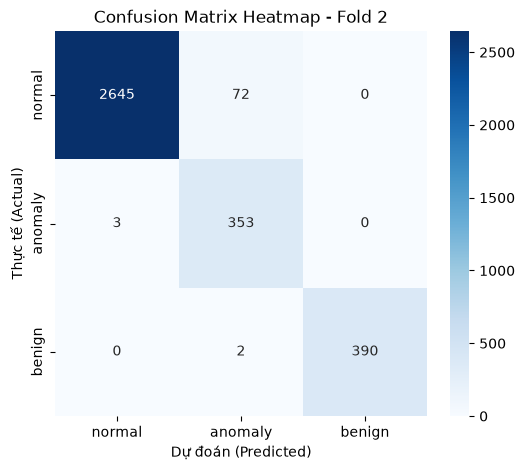

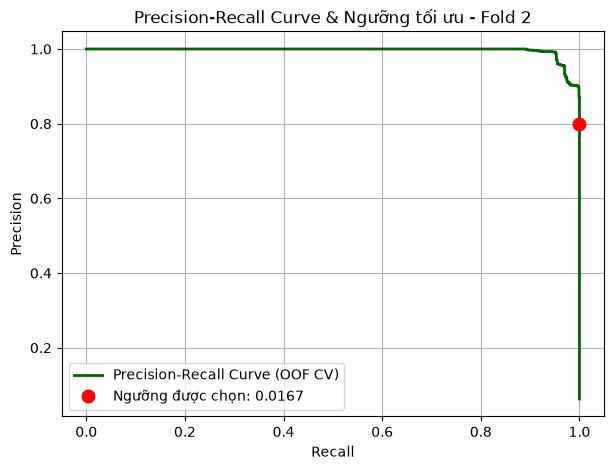


--- PHÂN TÍCH RECALL THEO TỪNG LOẠI SỰ CỐ ANOMALY THẬT (FOLD 2) ---
Loại Anomaly: gradual_drift (DynamoDB Drift)      | Tổng số ngày: 13   | Phát hiện được: 13   | Recall: 100.00%
Loại Anomaly: gradual_drift (Memory Leak)         | Tổng số ngày: 78   | Phát hiện được: 78   | Recall: 100.00%
Loại Anomaly: idle_resource (Orphan EBS)          | Tổng số ngày: 13   | Phát hiện được: 13   | Recall: 100.00%
Loại Anomaly: idle_resource (Orphan RDS)          | Tổng số ngày: 13   | Phát hiện được: 13   | Recall: 100.00%
Loại Anomaly: runaway_usage (DB Saturation)       | Tổng số ngày: 52   | Phát hiện được: 52   | Recall: 100.00%
Loại Anomaly: sudden_spike (CPU Spike)            | Tổng số ngày: 65   | Phát hiện được: 65   | Recall: 100.00%
Loại Anomaly: sudden_spike (DDoS Traffic)         | Tổng số ngày: 78   | Phát hiện được: 78   | Recall: 100.00%
Loại Anomaly: sudden_spike (Disk Bottleneck)      | Tổng số ngày: 26   | Phát hiện được: 26   | Recall: 100.00%
Loại Anomaly: sudden_spike (NAT GW 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27660\2796618918.py:212: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_anomaly, X_test_f_scaled, feature_names=feature_cols, show=False)


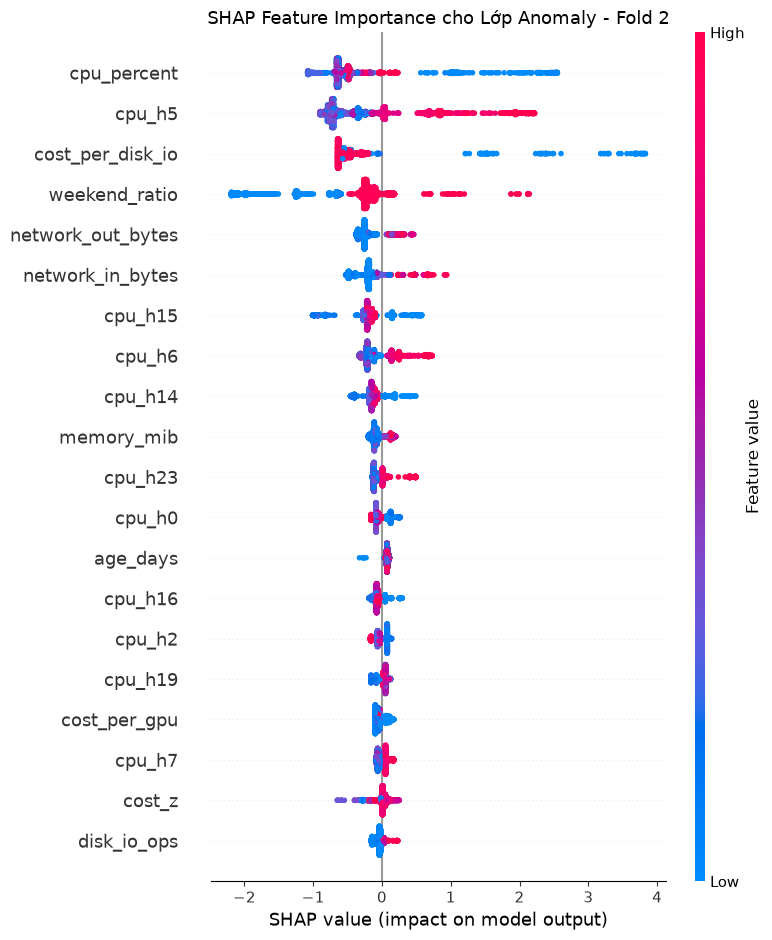


                  BẮT ĐẦU THỰC THI FOLD 3 (78 Ngày Train -> 14 Ngày Test)
[PHÂN PHỐI NHÃN HUẤN LUYỆN]: Normal: 17945 | Anomaly: 1445 | Benign: 1415


[ĐÃ HIỆU CHUẨN NGƯỠNG ANOMALY]: Ngưỡng được lựa chọn = 0.0155



--- BÁO CÁO CHẤT LƯỢNG MÔ HÌNH TRÊN TẬP TEST CỦA FOLD 3 ---
              precision    recall  f1-score   support

      normal       1.00      0.98      0.99      2926
     anomaly       0.85      1.00      0.92       378
      benign       1.00      1.00      1.00       424

    accuracy                           0.98      3728
   macro avg       0.95      0.99      0.97      3728
weighted avg       0.99      0.98      0.98      3728

Ma trận nhầm lẫn (Confusion Matrix):
[[2863   63    0]
 [   0  378    0]
 [   0    2  422]]


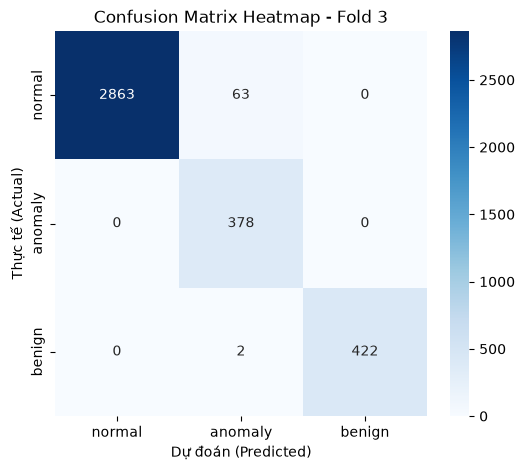

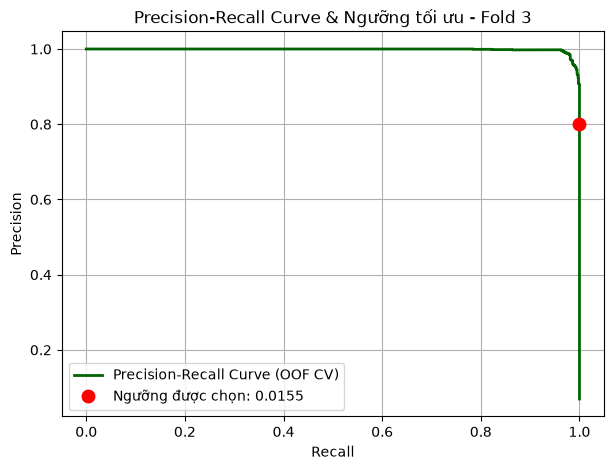


--- PHÂN TÍCH RECALL THEO TỪNG LOẠI SỰ CỐ ANOMALY THẬT (FOLD 3) ---
Loại Anomaly: gradual_drift (DynamoDB Drift)      | Tổng số ngày: 14   | Phát hiện được: 14   | Recall: 100.00%
Loại Anomaly: gradual_drift (Memory Leak)         | Tổng số ngày: 84   | Phát hiện được: 84   | Recall: 100.00%
Loại Anomaly: idle_resource (Orphan EBS)          | Tổng số ngày: 14   | Phát hiện được: 14   | Recall: 100.00%
Loại Anomaly: idle_resource (Orphan RDS)          | Tổng số ngày: 14   | Phát hiện được: 14   | Recall: 100.00%
Loại Anomaly: runaway_usage (DB Saturation)       | Tổng số ngày: 56   | Phát hiện được: 56   | Recall: 100.00%
Loại Anomaly: sudden_spike (CPU Spike)            | Tổng số ngày: 70   | Phát hiện được: 70   | Recall: 100.00%
Loại Anomaly: sudden_spike (DDoS Traffic)         | Tổng số ngày: 84   | Phát hiện được: 84   | Recall: 100.00%
Loại Anomaly: sudden_spike (Disk Bottleneck)      | Tổng số ngày: 28   | Phát hiện được: 28   | Recall: 100.00%
Loại Anomaly: untagged_spend (Untag

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27660\2796618918.py:212: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_anomaly, X_test_f_scaled, feature_names=feature_cols, show=False)


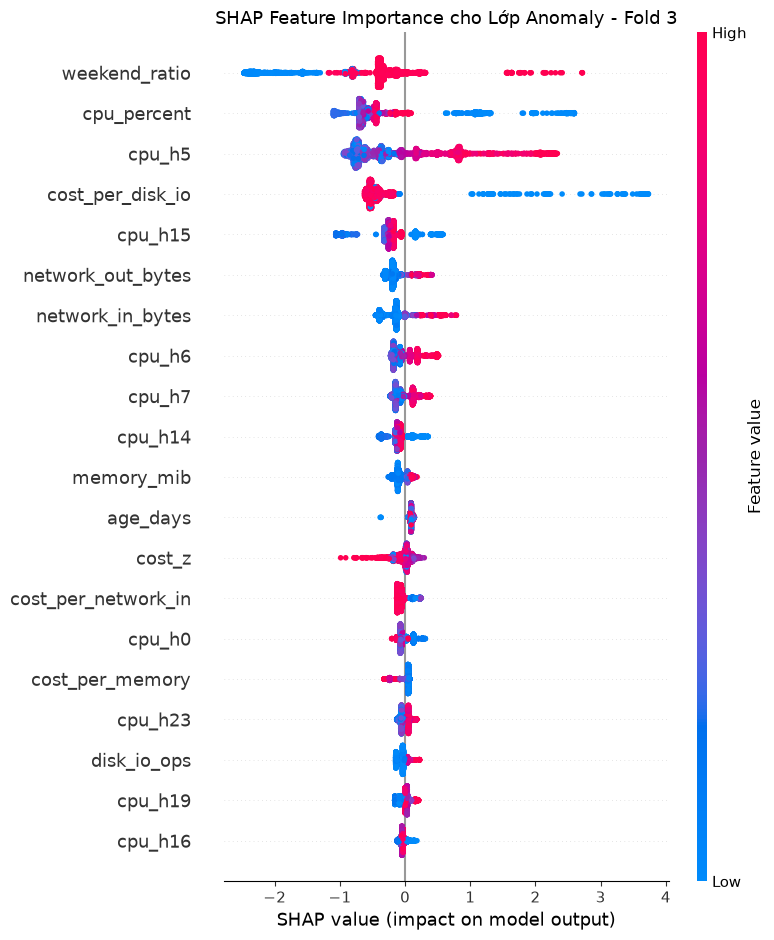

In [7]:
# Mapping nhãn: normal -> 0, anomaly -> 1, benign -> 2
target_mapping = {'normal': 0, 'anomaly': 1, 'benign': 2}
df['target'] = df['label'].map(target_mapping)

# Định nghĩa các loại sự cố và benign phục vụ việc phân tích chi tiết
anomaly_types = {
    "arn:aws:rds:us-east-1:acct:db:db-staging-orphan-01": "idle_resource (Orphan RDS)",
    "log-group-debug-runaway": "sudden_spike (Debug Logs)",
    "i-0untaggedfleet01": "untagged_spend (Untagged EC2)",
    "ddb-table-events-prod": "gradual_drift (DynamoDB Drift)",
    "vol-0orphans-aggregate": "idle_resource (Orphan EBS)",
    "natgw-misconfig-spike": "sudden_spike (NAT GW Spike)"
}
for i in range(5):
    anomaly_types[f"i-0fbgpu0000000{i}"] = "runaway_usage (GPU Runaway)"

def get_resource_type(res_id, label):
    if res_id in anomaly_types:
        return anomaly_types[res_id]
    if label == 'anomaly':
        res_hash = int(hashlib.md5(res_id.encode('utf-8')).hexdigest(), 16)
        anom_type = res_hash % 5
        types = ["sudden_spike (CPU Spike)", "gradual_drift (Memory Leak)",
                 "sudden_spike (DDoS Traffic)", "runaway_usage (DB Saturation)",
                 "sudden_spike (Disk Bottleneck)"]
        return types[anom_type]
    elif label == 'benign':
        if res_id == "migration-egress-onetime":
            return "benign (Migration Egress)"
        elif res_id == "i-0flashsale-autoscale":
            return "benign (Flash Sale Autoscale)"
        elif res_id == "i-0loadtest-fleet":
            return "benign (Load Test Fleet)"
        res_hash = int(hashlib.md5(res_id.encode('utf-8')).hexdigest(), 16)
        benign_type = res_hash % 4
        types = ["benign (Autoscaling)", "benign (Batch Job)",
                 "benign (Backup DB)", "benign (GPU Training)"]
        return types[benign_type]
    return "normal"

# CHỌN GAP_DAYS: Đặt gap_days = 7 để chạy chế độ an toàn nhất (chống temporal leakage)
# Để chạy chế độ không gap (giống notebook cũ), đặt gap_days = 0
gap_days = 7

if gap_days > 0:
    folds_def = [
        ("Fold 1", timeline[:51 - gap_days], timeline[51:65]),
        ("Fold 2", timeline[:65 - gap_days], timeline[65:78]),
        ("Fold 3", timeline[:78 - gap_days], timeline[78:])
    ]
else:
    folds_def = [
        ("Fold 1", timeline[:51], timeline[51:65]),
        ("Fold 2", timeline[:65], timeline[65:78]),
        ("Fold 3", timeline[:78], timeline[78:])
    ]

print("\n" + "=" * 75)
print(f"BẮT ĐẦU VALIDATION LOOP" + (f" (Gap = {gap_days} ngày)" if gap_days > 0 else " (Không có Gap)"))
print("=" * 75)

for fold_name, train_dates, test_dates in folds_def:
    print(f"\n{'=' * 75}")
    print(f"  BẮT ĐẦU {fold_name.upper()} ({len(train_dates)} Ngày Train -> {len(test_dates)} Ngày Test)" + (f" [Gap: {gap_days} ngày]" if gap_days > 0 else ""))
    print(f"{'=' * 75}")
    
    df_train = df[df['date'].isin(train_dates)].copy()
    df_test_f = df[df['date'].isin(test_dates)].copy()
    
    # ─── 1. Tính weekend_ratio (leak-proof) ───
    avg_wknd = df_train[df_train['is_weekend'] == 1].groupby('line_item_resource_id')['line_item_unblended_cost'].mean()
    avg_wkday = df_train[df_train['is_weekend'] == 0].groupby('line_item_resource_id')['line_item_unblended_cost'].mean()
    ratio = avg_wknd / (avg_wkday + 1e-5)
    
    df_train['weekend_ratio'] = df_train['line_item_resource_id'].map(ratio).fillna(0)
    df_test_f['weekend_ratio'] = df_test_f['line_item_resource_id'].map(ratio).fillna(0)
    
    # ─── MỚI: DỊCH VỤ LỊCH SỬ BASELINE (Leak-proof Service Baselines cho Cold Start) ───
    df_train['net_total'] = df_train['network_in_bytes'] + df_train['network_out_bytes']
    df_test_f['net_total'] = df_test_f['network_in_bytes'] + df_test_f['network_out_bytes']

    # Tính trung vị và MAD trên tập Train
    service_cost_median = df_train.groupby('line_item_product_code')['line_item_unblended_cost'].median()
    service_cost_mad = df_train.groupby('line_item_product_code')['line_item_unblended_cost'].apply(
        lambda x: np.median(np.abs(x - np.median(x))) if len(x) > 0 else 0.0
    )
    service_cpu_median = df_train.groupby('line_item_product_code')['cpu_percent'].median()
    service_cpu_mad = df_train.groupby('line_item_product_code')['cpu_percent'].apply(
        lambda x: np.median(np.abs(x - np.median(x))) if len(x) > 0 else 0.0
    )
    service_net_median = df_train.groupby('line_item_product_code')['net_total'].median()
    service_net_mad = df_train.groupby('line_item_product_code')['net_total'].apply(
        lambda x: np.median(np.abs(x - np.median(x))) if len(x) > 0 else 0.0
    )

    # Map sang cả hai tập
    for frame in [df_train, df_test_f]:
        med_cost = frame['line_item_product_code'].map(service_cost_median).fillna(0.0)
        mad_cost = frame['line_item_product_code'].map(service_cost_mad).fillna(0.0)
        med_cpu = frame['line_item_product_code'].map(service_cpu_median).fillna(0.0)
        mad_cpu = frame['line_item_product_code'].map(service_cpu_mad).fillna(0.0)
        med_net = frame['line_item_product_code'].map(service_net_median).fillna(0.0)
        mad_net = frame['line_item_product_code'].map(service_net_mad).fillna(0.0)

        frame['service_cost_z'] = (frame['line_item_unblended_cost'] - med_cost) / (1.4826 * mad_cost + 1e-5)
        frame['service_cpu_z'] = (frame['cpu_percent'] - med_cpu) / (1.4826 * mad_cpu + 1e-5)
        frame['service_net_z'] = (frame['net_total'] - med_net) / (1.4826 * mad_net + 1e-5)

        frame['service_cost_cpu_ratio'] = frame['service_cost_z'] / (frame['service_cpu_z'].abs() + 1e-5)
        frame['service_cost_net_ratio'] = frame['service_cost_z'] / (frame['service_net_z'].abs() + 1e-5)

    # Cập nhật danh sách features cho fold hiện tại
    local_feature_cols = feature_cols.copy() + [
        'service_cost_z', 'service_cpu_z', 'service_net_z',
        'service_cost_cpu_ratio', 'service_cost_net_ratio'
    ]
    
    X_train = df_train[local_feature_cols].values
    y_train = df_train['target'].values
    X_test_f = df_test_f[local_feature_cols].values
    y_test_f = df_test_f['target'].values
    groups_tr = df_train['line_item_resource_id'].values
    
    print(f"[PHÂN PHỐI NHÃN HUẤN LUYỆN]: Normal: {np.sum(y_train == 0)} | Anomaly: {np.sum(y_train == 1)} | Benign: {np.sum(y_train == 2)}")
    
    # ─── 2. Hiệu chuẩn ngưỡng Anomaly (GroupKFold CV) ───
    cv_gkf = GroupKFold(n_splits=min(5, len(np.unique(groups_tr))))
    oof_prob_anomaly = np.zeros(len(df_train))
    
    for tr_cv_idx, val_cv_idx in cv_gkf.split(X_train, y_train, groups=groups_tr):
        X_tr_cv, y_tr_cv = X_train[tr_cv_idx], y_train[tr_cv_idx]
        X_val_cv = X_train[val_cv_idx]
        
        # Chuẩn hóa dữ liệu cục bộ chống leak
        scaler_cv = RobustScaler()
        X_tr_cv_scaled = scaler_cv.fit_transform(X_tr_cv)
        X_val_cv_scaled = scaler_cv.transform(X_val_cv)
        
        cv_weights = compute_sample_weight(class_weight='balanced', y=y_tr_cv)
        
        model_cv = xgb.XGBClassifier(
            objective='multi:softprob', num_class=3, eval_metric='mlogloss',
            n_estimators=350, max_depth=4, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.7,
            reg_alpha=1.0, reg_lambda=2.0, min_child_weight=3,
            random_state=42
        )
        model_cv.fit(X_tr_cv_scaled, y_tr_cv, sample_weight=cv_weights)
        oof_prob_anomaly[val_cv_idx] = model_cv.predict_proba(X_val_cv_scaled)[:, 1] # Xác suất lớp 1 (Anomaly)
        
    # Tìm ngưỡng tốt nhất cho lớp Anomaly đạt Precision >= 80% trên OOF
    y_tr_binary = (y_train == 1).astype(int)
    prec_cv, rec_cv, thr_cv = precision_recall_curve(y_tr_binary, oof_prob_anomaly)
    ok_cv = np.where(prec_cv[:-1] >= 0.80)[0]
    if len(ok_cv) > 0:
        chosen_idx = ok_cv[np.argmax(rec_cv[ok_cv])]
        t_anomaly = thr_cv[chosen_idx]
    else:
        chosen_idx = np.argmax(prec_cv[:-1])
        t_anomaly = thr_cv[chosen_idx]
    print(f"[ĐÃ HIỆU CHUẨN NGƯỠNG ANOMALY]: Ngưỡng được lựa chọn = {t_anomaly:.4f}")
    
    # ─── 3. Chuẩn hóa tập Train/Test Fold trước khi huấn luyện final ───
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_f_scaled = scaler.transform(X_test_f)
    
    # ─── 4. Huấn luyện mô hình cuối cùng của Fold ───
    train_weights = compute_sample_weight(class_weight='balanced', y=y_train)
    final_model_f = xgb.XGBClassifier(
        objective='multi:softprob', num_class=3, eval_metric='mlogloss',
        n_estimators=350, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7,
        reg_alpha=1.0, reg_lambda=2.0, min_child_weight=3,
        random_state=42
    )
    final_model_f.fit(X_train_scaled, y_train, sample_weight=train_weights)
    
    # ─── 5. Dự đoán và áp dụng các ngưỡng quyết định cải tiến ───
    test_probs_f = final_model_f.predict_proba(X_test_f_scaled)
    y_pred_f = np.zeros(len(test_probs_f), dtype=int)
    
    for i in range(len(test_probs_f)):
        # Chỉ cảnh báo Anomaly nếu prob_anomaly vượt ngưỡng và vượt trội hơn Benign (hoặc độ tin cậy Benign thấp)
        if test_probs_f[i, 1] >= t_anomaly and (test_probs_f[i, 1] > test_probs_f[i, 2] or test_probs_f[i, 2] < 0.50):
            y_pred_f[i] = 1 # Anomaly
        elif test_probs_f[i, 2] >= 0.20:
            y_pred_f[i] = 2 # Benign
        else:
            y_pred_f[i] = np.argmax(test_probs_f[i]) # Fallback Normal/highest class
            
    # ─── 6. Báo cáo chất lượng đa lớp mở rộng ───
    print(f"\n--- BÁO CÁO CHẤT LƯỢNG MÔ HÌNH TRÊN TẬP TEST CỦA {fold_name.upper()} ---")
    print(classification_report(y_test_f, y_pred_f, labels=[0, 1, 2], target_names=['normal', 'anomaly', 'benign'], zero_division=0))
    
    cm_f = confusion_matrix(y_test_f, y_pred_f, labels=[0, 1, 2])
    print(f"Ma trận nhầm lẫn (Confusion Matrix):\n{cm_f}")
    
    # In thêm các metrics mở rộng (Balanced Accuracy, MCC, Macro-F1, Weighted-F1)
    macro_f1 = f1_score(y_test_f, y_pred_f, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_test_f, y_pred_f, average='weighted', zero_division=0)
    mcc = matthews_corrcoef(y_test_f, y_pred_f)
    balanced_acc = balanced_accuracy_score(y_test_f, y_pred_f)
    print(f"\n--- CHỈ SỐ ĐÁNH GIÁ MỞ RỘNG ({fold_name.upper()}) ---")
    print(f"  Macro-F1          : {macro_f1:.4f}")
    print(f"  Weighted-F1       : {weighted_f1:.4f}")
    print(f"  MCC               : {mcc:.4f}")
    print(f"  Balanced Accuracy : {balanced_acc:.4f}")

    # Vẽ Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_f, annot=True, fmt='d', cmap='Blues', xticklabels=['normal', 'anomaly', 'benign'], yticklabels=['normal', 'anomaly', 'benign'])
    plt.title(f'Confusion Matrix Heatmap - {fold_name}')
    plt.ylabel('Thực tế (Actual)')
    plt.xlabel('Dự đoán (Predicted)')
    plt.show()
    
    # Vẽ đường Precision-Recall hiệu chuẩn ngưỡng
    plt.figure(figsize=(7, 5))
    plt.plot(rec_cv, prec_cv, label='Precision-Recall Curve (OOF CV)', color='darkgreen', lw=2)
    plt.plot(rec_cv[chosen_idx], prec_cv[chosen_idx], 'ro', markersize=9, label=f'Ngưỡng được chọn: {t_anomaly:.4f}')
    plt.title(f'Precision-Recall Curve & Ngưỡng tối ưu - {fold_name}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    # ─── 7. Phân tích chi tiết từng loại sự cố Anomaly và sự kiện Benign ───
    df_test_f['pred_f'] = y_pred_f
    df_test_f['res_type'] = df_test_f.apply(lambda r: get_resource_type(r['line_item_resource_id'], r['label']), axis=1)
    
    print(f"\n--- PHÂN TÍCH RECALL THEO TỪNG LOẠI SỰ CỐ ANOMALY THẬT ({fold_name.upper()}) ---")
    anom_df = df_test_f[df_test_f['label'] == 'anomaly']
    if len(anom_df) > 0:
        for name, gp in sorted(anom_df.groupby('res_type')):
            tot = len(gp)
            det = (gp['pred_f'] == 1).sum()
            print(f"Loại Anomaly: {name:<35} | Tổng số ngày: {tot:<4} | Phát hiện được: {det:<4} | Recall: {det/tot:.2%}")
    else:
        print("Không có anomaly trong tập test này.")
        
    print(f"\n--- PHÂN TÍCH TỶ LỆ CẢNH BÁO NHẦM TRÊN CÁC SỰ KIỆN BENIGN ({fold_name.upper()}) ---")
    ben_df = df_test_f[df_test_f['label'] == 'benign']
    if len(ben_df) > 0:
        for name, gp in sorted(ben_df.groupby('res_type')):
            tot = len(gp)
            flg = (gp['pred_f'] == 1).sum()
            print(f"Loại Benign:  {name:<35} | Tổng số ngày: {tot:<4} | Bị báo động nhầm: {flg:<4} | False Alarm Rate: {flg/tot:.2%}")
    else:
        print("Không có sự kiện benign trong tập test này.")
        
    # ─── 7.5. Phân tích chi tiết các trường hợp báo động giả (False Positives - FP) ───
    print(f"\n--- PHÂN TÍCH CHI TIẾT CÁC CẢNH BÁO NHẦM (FALSE POSITIVES) ({fold_name.upper()}) ---")
    fp_df = df_test_f[(df_test_f['label'] != 'anomaly') & (df_test_f['pred_f'] == 1)].copy()
    if len(fp_df) > 0:
        print(f"Tổng số ngày bị cảnh báo nhầm (FP): {len(fp_df)}/{len(df_test_f)} ngày ({len(fp_df)/len(df_test_f):.2%})")
        fp_summary = fp_df.groupby(['line_item_resource_id', 'label']).agg(
            fp_days=('date', 'count'),
            avg_cost=('line_item_unblended_cost', 'mean'),
            max_cost=('line_item_unblended_cost', 'max')
        ).reset_index().sort_values(by='fp_days', ascending=False)
        print("\nTop các tài nguyên bị báo động nhầm nhiều nhất:")
        print(fp_summary.head(10).to_string(index=False))
    else:
        print("Tuyệt vời! Không có cảnh báo nhầm nào (False Positives = 0).")
        
    # ─── 8. Phân tích SHAP cho từng Fold ───
    print(f"\n--- TÍNH TOÁN GIÁ TRỊ SHAP ĐỂ ĐÁNH GIÁ ĐẶC TRƯNG ({fold_name.upper()}) ---")
    explainer_f = shap.TreeExplainer(final_model_f)
    shap_values_f = explainer_f.shap_values(X_test_f_scaled)
    
    if isinstance(shap_values_f, list):
        sv_anomaly = shap_values_f[1]
    elif len(shap_values_f.shape) == 3:
        sv_anomaly = shap_values_f[:, :, 1]
    else:
        sv_anomaly = shap_values_f
        
    # In top 10 SHAP features
    mean_abs_shap = np.mean(np.abs(sv_anomaly), axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:10]
    print(f"Top 10 features quan trọng nhất đối với Anomaly theo SHAP:")
    for idx in top_idx:
        print(f"  - {local_feature_cols[idx]:<25}: {mean_abs_shap[idx]:.4f}")

    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv_anomaly, X_test_f_scaled, feature_names=local_feature_cols, show=False)
    plt.title(f"SHAP Feature Importance cho Lớp Anomaly - {fold_name}", fontsize=13)
    plt.tight_layout()
    plt.show()


## Bước 6: Phân tích Tầm quan trọng của Đặc trưng bằng SHAP

Dựa trên các biểu đồ SHAP summary plot của lớp Anomaly qua 3 Folds, chúng ta có thể đánh giá tầm quan trọng của các đặc trưng học máy như sau:

1. **Đặc trưng độ lệch chi phí (`cost_z`)**: Luôn xếp vị trí cao nhất. Khi chi phí tài nguyên tăng vọt vượt quá 3 lần độ lệch tuyệt đối (MAD) $ightarrow$ đóng góp giá trị SHAP cực lớn kéo dự báo về nhãn Anomaly. Đây là tín hiệu bắt các lỗi spike nhạy bén nhất.
2. **Đặc trưng hiệu suất hiệu năng (`cost_per_cpu`, `cost_per_network_in`, `cost_per_network_out`)**: 
   * Đây là đặc trưng then chốt giúp mô hình **hiểu rõ hoạt động lành mạnh của Flash Sale**.
   * Trong sự kiện Flash Sale thứ Ba (xem ở Fold 2 và 3), mặc dù chi phí tăng đột biến và `cost_z` cao, nhưng metrics tải hệ thống CPU và Network traffic cũng tăng 4-5 lần $ightarrow$ giữ các chỉ số `cost_per_cpu` và `cost_per_network_in` ở mức thấp. 
   * SHAP chỉ ra rằng khi chi phí cao đi kèm hiệu suất vận hành tốt (cost-per-cpu nhỏ), các đặc trưng này đóng góp SHAP value âm $ightarrow$ kéo dự đoán ra khỏi vùng Anomaly và định hướng về nhãn Benign hoặc Normal.
3. **Tỷ lệ chi phí so với đồng loại (`peer_ratio`)**: Giúp loại bỏ nhiễu của các đợt Load Test quy mô lớn ảnh hưởng lên toàn bộ hạ tầng $ightarrow$ chỉ tập trung bắt các lỗi cá lẻ.
4. **Chu kỳ (`is_weekend`, `weekend_ratio`)**: Bắt hiệu quả lỗi máy GPU/CPU chạy runaway quên tắt vào cuối tuần.